<a href="https://colab.research.google.com/github/Isabel160609/Cuadernos-colab-Pyton/blob/main/Copy_of_EDA_Ejercicio_con_empresas_unicorn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imagina que acabamos de descargar el dataset de "Unicorn Companies" (empresas que valen más de $1,000 millones de USD). Vamos a usar la librería pandas, que es el estándar de oro en la industria.

In [ ]:
import pandas as pd

# Creamos un mini-dataset para practicar (Simulando el CSV que falló)
data = {
    'Company': ['ByteDance', 'SpaceX', 'SHEIN', 'Stripe', 'Canva'],
    'Valuation': ['$225B', '$150B', '$66B', '$50B', '$40B'],
    'Country': ['China', 'USA', 'China', 'USA', 'Australia']
}

df = pd.DataFrame(data)

print("--- Dataset Original (Valuation es texto) ---")
print(df)
print(df.dtypes) # Verás que Valuation es 'object' (texto)

--- Dataset Original (Valuation es texto) ---
     Company Valuation    Country
0  ByteDance     $225B      China
1     SpaceX     $150B        USA
2      SHEIN      $66B      China
3     Stripe      $50B        USA
4      Canva      $40B  Australia
Company      object
Valuation    object
Country      object
dtype: object


La Transformación (Cleaning & Structuring)
Como mencionamos, Python no puede sumar 225B + $150B. Necesitamos limpiar esos datos. Para ello usaremos los métodos .str.replace() y cambiaremos el tipo de dato con .astype().





In [ ]:
# 1. Quitamos el símbolo '$' y la 'B'
df['Valuation_Numeric'] = df['Valuation'].str.replace('$', '', regex=False).str.replace('B', '', regex=False)

# 2. Convertimos a número flotante (decimal)
df['Valuation_Numeric'] = df['Valuation_Numeric'].astype(float)

print("\n--- Dataset Limpio ---")
print(df)
print(f"\nLa valoración total es: ${df['Valuation_Numeric'].sum()} Billones")


--- Dataset Limpio ---
     Company Valuation    Country  Valuation_Numeric
0  ByteDance     $225B      China              225.0
1     SpaceX     $150B        USA              150.0
2      SHEIN      $66B      China               66.0
3     Stripe      $50B        USA               50.0
4      Canva      $40B  Australia               40.0

La valoración total es: $531.0 Billones


¿Qué acabamos de hacer?
Cleaning: Identificamos caracteres que "ensuciaban" nuestros números.

Validation: Al imprimir df.dtypes o el resultado de la suma, validamos que la transformación fue exitosa.

Iteration: Si encontráramos una empresa con valor en "M" (Millions), tendríamos que volver atrás y ajustar nuestra lógica. ¡Eso es el EDA!

1. Filtrar por condición numérica (Valuación > $100B)
Queremos ver solo las empresas que están en el "club de los 100".

In [ ]:
# Filtramos las filas donde Valuation_Numeric sea mayor a 100
top_unicorns = df[df['Valuation_Numeric'] > 100]

print("--- Unicornios de más de $100B ---")
print(top_unicorns)

--- Unicornios de más de $100B ---
     Company Valuation Country  Valuation_Numeric
0  ByteDance     $225B   China              225.0
1     SpaceX     $150B     USA              150.0


2. Filtrar por texto (Empresas de USA)
Aquí buscamos coincidencias exactas en la columna de país.
Al filtrar, estás practicando el Discovering (Descubrimiento). Estás respondiendo preguntas específicas como:

¿Hay una concentración de riqueza en un país específico?

¿Cuántas empresas realmente dominan el mercado?

In [ ]:
# Filtramos por país
usa_unicorns = df[df['Country'] == 'USA']

print("\n--- Unicornios en USA ---")
print(usa_unicorns)


--- Unicornios en USA ---
  Company Valuation Country  Valuation_Numeric
1  SpaceX     $150B     USA              150.0
3  Stripe      $50B     USA               50.0


El método groupby() es como el "pivote" de las tablas dinámicas en Excel, pero mucho más rápido y flexible. Es una pieza clave del Structuring en el EDA.

Para este nivel, vamos a usar una función que se llama agregación. Básicamente, le decimos a Python: "Junta a todos los que sean del mismo país y calcula algo para ellos (la suma, el promedio, el conteo, etc.)".

Agrupación y Resumen de Datos
Aquí tienes el código para ver el poder de los países en el mundo de los unicornios:

In [ ]:
# Agrupamos por 'Country' y calculamos el promedio y la suma de 'Valuation_Numeric'
resumen_paises = df.groupby('Country')['Valuation_Numeric'].agg(['mean', 'sum', 'count'])

# Renombramos las columnas para que sean más claras
resumen_paises.columns = ['Promedio_B', 'Total_B', 'Cantidad_Empresas']

print("--- Análisis de Valuación por País ---")
print(resumen_paises.sort_values(by='Total_B', ascending=False))

--- Análisis de Valuación por País ---
           Promedio_B  Total_B  Cantidad_Empresas
Country                                          
China           145.5    291.0                  2
USA             100.0    200.0                  2
Australia        40.0     40.0                  1


¿Qué nos dice esto? (Insight de Analista)
Al ejecutar esto, podrías descubrir cosas interesantes:

China podría tener menos empresas pero con un Promedio_B altísimo.

USA podría tener muchas más empresas pero con un promedio más variado.

Esto es Validating en acción: estás confirmando si el volumen de empresas de un país se traduce proporcionalmente en valor de mercado.

¿Cuál es nuestro siguiente movimiento?
Ya sabemos importar, limpiar, filtrar y agrupar. Lo que sigue es la joya de la corona del EDA: Presenting (Visualización).

Un analista de datos rara vez entrega una tabla de números; entregamos gráficos que cuentan una historia. En Python usamos librerías como matplotlib o seaborn.

En Python, la librería más común para empezar es matplotlib. Vamos a crear un gráfico de barras que compare las empresas y sus valuaciones. Esto entra en la fase de Presenting de nuestro proceso EDA.

Creando tu primera visualización
Copia y ejecuta este código (asegúrate de haber ejecutado los pasos anteriores para tener el df listo):

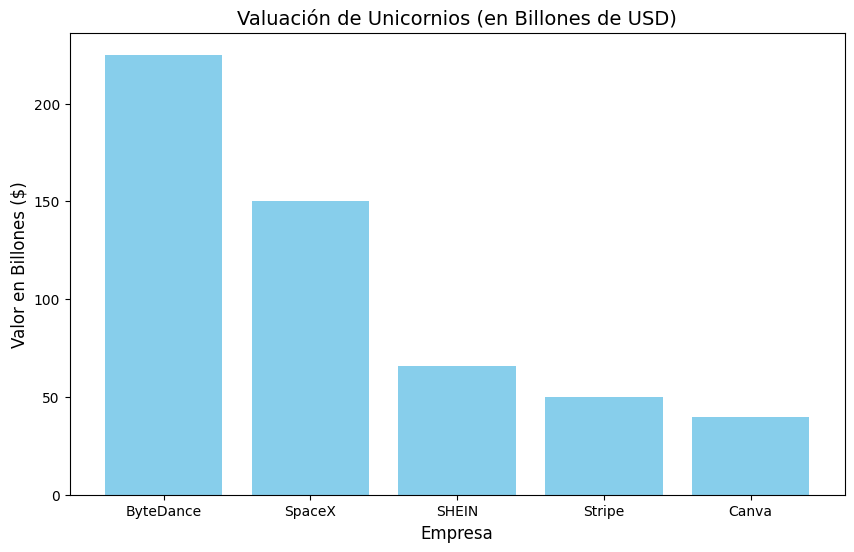

In [ ]:
import matplotlib.pyplot as plt

# 1. Configuramos el tamaño del gráfico
plt.figure(figsize=(10, 6))

# 2. Creamos el gráfico de barras
# Usamos la columna de nombres de empresas y su valor numérico
plt.bar(df['Company'], df['Valuation_Numeric'], color='skyblue')

# 3. Añadimos títulos y etiquetas (¡La comunicación es clave!)
plt.title('Valuación de Unicornios (en Billones de USD)', fontsize=14)
plt.xlabel('Empresa', fontsize=12)
plt.ylabel('Valor en Billones ($)', fontsize=12)

# 4. Mostramos el gráfico
plt.show()

¿Qué logramos con este gráfico?
Al ver las barras, el cerebro humano detecta inmediatamente las proporciones.

Outliers: Notarás enseguida si una empresa como ByteDance "se sale del mapa" comparada con las demás.

Storytelling: Ya no estás diciendo "esta empresa vale 225", estás mostrando cuánto más grande es respecto a su competencia.

¿Qué hemos aprendido hoy en este ciclo EDA?
Hemos recorrido las 6 prácticas de forma iterativa y no secuencial:

Discovering: Vimos la estructura inicial.

Structuring: Creamos el DataFrame y agrupamos.

Cleaning: Quitamos los símbolos de $ y B.

Validating: Comprobamos que los números sumaban correctamente.

Presenting: Creamos este gráfico.

En el mundo real, los datasets son "sucios". Imagina que alguien olvidó anotar la valuación de una empresa o el país de origen. En Python, estos espacios vacíos se representan como NaN (Not a Number).

Como analista, tienes tres caminos ante un dato faltante:

Eliminarlo (si tienes muchos datos y ese registro no aporta).

Investigarlo y llenarlo manualmente.

Imputarlo (llenarlo usando la lógica, como el promedio o la moda).

Paso 1: Simulando el desastre (Datos faltantes)
Vamos a añadir un par de empresas nuevas a nuestro DataFrame, pero "accidentalmente" dejaremos datos vacíos usando la librería numpy.

In [ ]:
import numpy as np

# Creamos nuevos datos con valores nulos (NaN)
new_data = {
    'Company': ['OpenAI', 'Anthropic'],
    'Valuation': [None, None], # Datos faltantes
    'Country': ['USA', np.nan], # El país de Anthropic también falta
    'Valuation_Numeric': [np.nan, 20.0] # A OpenAI le falta el valor
}

df_nulos = pd.concat([df, pd.DataFrame(new_data)], ignore_index=True)

print("--- Dataset con valores nulos ---")
print(df_nulos.isnull().sum()) # Esto nos dice cuántos nulos hay por columna

--- Dataset con valores nulos ---
Company              0
Valuation            2
Country              1
Valuation_Numeric    1
dtype: int64


**Paso 2:** La "Cura" (Data Imputation)
Vamos a usar una técnica común: llenar el valor faltante de Valuation_Numeric con el promedio del resto de las empresas. Esto es parte de la Limpieza y Estructuración.

In [ ]:
# 1. Calculamos el promedio de las empresas que SÍ tienen dato
promedio = df_nulos['Valuation_Numeric'].mean()

# 2. Llenamos los nulos con ese promedio usando .fillna()
df_nulos['Valuation_Numeric'] = df_nulos['Valuation_Numeric'].fillna(promedio)

# 3. Para el país (que es texto), usaremos "Unknown"
df_nulos['Country'] = df_nulos['Country'].fillna('Unknown')

print("\n--- Dataset 'Curado' ---")
print(df_nulos.tail())


--- Dataset 'Curado' ---
     Company Valuation    Country  Valuation_Numeric
2      SHEIN      $66B      China          66.000000
3     Stripe      $50B        USA          50.000000
4      Canva      $40B  Australia          40.000000
5     OpenAI      None        USA          91.833333
6  Anthropic      None    Unknown          20.000000
